# MRCT — Matriz de Resiliencia Climática Territorial
## Tutorial Académico: Del píxel Landsat al índice de resiliencia ecosistémica

**Autores:** John Treimun Ríos · Denis Berroeta  
**Institución:** Centro de Inteligencia Territorial — Universidad Adolfo Ibáñez  
**Versión del modelo:** MRCT v1 · Python 3.10+

---

### ¿Qué es MRCT?

MRCT es un modelo de **ecología cuantitativa satelital** que traduce series temporales de imágenes Landsat 8 (2013–2025) en índices de resiliencia ecosistémica para cuencas hidrográficas de la Patagonia chilena (Región de Aysén).

El modelo responde a una pregunta central:
> *¿Qué tan lejos está hoy una cuenca de su estado ecosistémico histórico de referencia, y qué capacidad tiene de absorber perturbaciones futuras?*

### Arquitectura del modelo (4 capas)

```
Capa 4 — Prospectiva y riesgo       → DELTA_RES, TRI, ETEI, DECISION_ZONE
           ↑
Capa 3 — Núcleo MRCT                → Domain, Velocidad, SENS, PT, RES
           ↑
Capa 2 — Indicadores anuales        → VEG, IRV, WA, PN, ALB, TB, NP, MPA...
           ↑
Capa 1 — Infraestructura            → Rasters Landsat, cuencas, máscaras
```

### Índice del notebook

| Sección | Contenido |
|---------|----------|
| 1 | Configuración del entorno e imports |
| 2 | Configuración del proyecto (MRCTConfig) |
| 3 | Carga de insumos espaciales |
| 4 | Indicadores anuales por cuenca (VEG, IRV, WA, PN, ALB, TB, paisaje) |
| 5 | Construcción del hipercubo tensorial y panel RID × Año |
| 6 | Dominio Ecosistémico Global (Mahalanobis + Ledoit-Wolf) |
| 7 | Dinámica temporal (Velocidad, Aceleración, Jerk) |
| 8 | Sensibilidad climática y Dominio local (KNN) |
| 9 | Potencial de Transición y Resiliencia |
| 10 | Escenario Prospectivo (cambio antrópico futuro) |
| 11 | Métricas de riesgo territorial (TRI, ETEI, DECISION_ZONE) |
| 12 | Visualizaciones y exportación de resultados |

---
## Sección 1 — Configuración del Entorno

In [2]:
# Verificar dependencias instaladas
import importlib, sys

required = [
    "numpy", "pandas", "geopandas", "rasterio",
    "scipy", "xarray", "sklearn", "matplotlib", "openpyxl"
]
missing = [pkg for pkg in required if importlib.util.find_spec(pkg) is None]

if missing:
    print(f"⚠️  Dependencias faltantes: {missing}")
    print("Instalar con: uv pip install", " ".join(missing))
else:
    print("✅ Todas las dependencias están instaladas.")

✅ Todas las dependencias están instaladas.


In [3]:
from pathlib import Path
import sys

# ─── Agregar el proyecto al path de Python ───────────────────────────────────
# Ajustar esta ruta si ejecutas el notebook desde una ubicación distinta
PROJECT_ROOT = Path(".").resolve().parent if Path(".").resolve().name == "notebooks" \
               else Path(".").resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print(f"Raíz del proyecto: {PROJECT_ROOT}")

# ─── Imports principales ──────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import geopandas as gpd
import rasterio
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.ticker import MaxNLocator
import warnings
warnings.filterwarnings("ignore")

%matplotlib inline
plt.rcParams["figure.dpi"] = 120
plt.rcParams["font.family"] = "sans-serif"

print("✅ Imports completados.")

Raíz del proyecto: /Users/denisberroeta/Documents/CIT/MRCT-2026/MRCT-Resiliencia
✅ Imports completados.


---
## Sección 2 — Configuración del Proyecto

### `MRCTConfig`: el objeto central de configuración

Toda la configuración del modelo vive en un único objeto `MRCTConfig`. Esto evita variables globales dispersas y permite reproducibilidad: dos corridas con distintos `config` son comparables.

**Insumos requeridos:**

| Archivo | Descripción |
|---------|-------------|
| `basins_aligned.tif` | Raster con el ID de cuenca (RID) por píxel |
| `anthropic_aligned.tif` | Índice de huella antrópica actual (0–1) |
| `R12_cuencas_nema_v2.shp` | Polígonos de cuencas con campo `RID` |
| `data/mosaics/{año}/L8/*.tif` | Mosaicos Landsat 8 anuales (NDVI, NDWI, NDSI, NDDI, ALB, TB) |

> **Nota:** Todos los rasters deben compartir la misma grilla (CRS, resolución, extensión) que `basins_aligned.tif`. La librería realineará automáticamente cualquier discrepancia.

### 🔧 Parámetros principales modificables

| Parámetro | Valor por defecto | Efecto al modificarlo |
|-----------|-------------------|----------------------|
| `thresh_veg` | 0.2 | Umbral NDVI para considerar un píxel como vegetado. Subirlo → menos vegetación detectada |
| `thresh_water` | 0.2 | Umbral NDWI para agua superficial |
| `thresh_snow` | 0.4 | Umbral NDSI para nieve/hielo |
| `baseline_years` | 2013–2022 | Años usados como referencia histórica del dominio |
| `alpha` | 1.0 | Peso de la sensibilidad climática en PT. Mayor α → cuencas climáticamente sensibles tienen mayor PT |
| `beta_local` | 0.5 | Peso del contexto espacial (vecindad KNN) en PT |
| `knn_k` | 8 | Número de cuencas vecinas para dominio local |
| `frag_alpha` | 0.6 | Intensidad del efecto de fragmentación inducida (escenario futuro) |
| `spillover` | 0.3 | Propagación espacial del cambio antrópico hacia cuencas vecinas |

In [4]:
from mrct.core.config import MRCTConfig

# ─────────────────────────────────────────────────────────────────────────────
# 🔧 AJUSTA ESTAS RUTAS A TU ENTORNO
# ─────────────────────────────────────────────────────────────────────────────
ROOT = PROJECT_ROOT

config = MRCTConfig(
    root=ROOT,

    # Insumos espaciales base
    basin_raster  = ROOT / "data" / "inputs" / "basins_aligned.tif",
    anthropic_raster = ROOT / "data" / "inputs" / "anthropic_aligned.tif",
    basin_shp     = ROOT / "data" / "inputs" / "R12_cuencas_nema_v2.shp",

    # Mosaicos Landsat 8 anuales (estructura: {mosaics_root}/{año}/L8/*.tif)
    mosaics_root  = ROOT / "data" / "mosaics",

    # Carpeta de salida (se crea si no existe)
    output_folder = ROOT / "data" / "MRCT_outputs",

    # Raster de huella antrópica futura (opcional; si no existe, usa el actual)
    scenario_anthropic_raster = ROOT / "data" / "inputs" / "anthropic_aligned_2.tif",

    # ── Años a procesar ──────────────────────────────────────────────────────
    years          = list(range(2013, 2025)),   # 🔧 ajustar si tienes menos años
    baseline_years = list(range(2013, 2023)),   # 🔧 años de referencia histórica

    # ── Umbrales temáticos ───────────────────────────────────────────────────
    thresh_veg     = 0.2,   # 🔧 NDVI mínimo para vegetación
    thresh_water   = 0.2,   # 🔧 NDWI mínimo para agua superficial
    thresh_snow    = 0.4,   # 🔧 NDSI mínimo para nieve/hielo
    thresh_wetland = 0.1,   # 🔧 NDWI mínimo para humedales

    # ── Parámetros de dominio ────────────────────────────────────────────────
    domain_metric  = "mahalanobis",  # 🔧 alternativa: "bisquare"

    # ── Parámetros de resiliencia ────────────────────────────────────────────
    alpha          = 1.0,   # 🔧 peso de sensibilidad climática en PT
    beta_local     = 0.5,   # 🔧 peso del dominio local (KNN) en PT
    knn_k          = 8,     # 🔧 vecinos para dominio local

    # ── Parámetros de escenario prospectivo ──────────────────────────────────
    frag_alpha     = 0.6,   # 🔧 intensidad de fragmentación inducida
    spillover      = 0.3,   # 🔧 propagación espacial antrópica
)

# Verificar qué archivos existen
print("Verificación de insumos:")
checks = [
    ("basin_raster",   config.basin_raster),
    ("anthropic_raster", config.anthropic_raster),
    ("basin_shp",      config.basin_shp),
    ("mosaics_root",   config.mosaics_root),
]
for name, path in checks:
    status = "✅" if path.exists() else "❌ FALTANTE"
    print(f"  {status}  {name}: {path.name}")

# Verificar años de mosaicos disponibles
available_years = sorted([
    int(p.name) for p in config.mosaics_root.iterdir()
    if p.is_dir() and p.name.isdigit()
]) if config.mosaics_root.exists() else []
print(f"\n  Años de mosaicos disponibles: {available_years}")

Verificación de insumos:
  ✅  basin_raster: basins_aligned.tif
  ✅  anthropic_raster: anthropic_aligned.tif
  ✅  basin_shp: R12_cuencas_nema_v2.shp
  ✅  mosaics_root: mosaics

  Años de mosaicos disponibles: [2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]


---
## Sección 3 — Carga de Insumos Espaciales

### El raster de cuencas (`basins_aligned.tif`)

Este raster codifica a qué cuenca pertenece cada píxel. El valor de cada celda es el **RID** (River ID) de la cuenca hidrográfica. Este es el insumo más crítico del modelo: define la unidad de análisis.

```
┌─────────────────────────────────────┐
│  píxel (i,j)  →  RID = 1042        │
│  píxel (i,j+1) → RID = 1042        │
│  píxel (i,j+2) → RID = 1089        │  ← otra cuenca
└─────────────────────────────────────┘
```

La **máscara natural** filtra píxeles con alta huella antrópica para que el análisis se centre en ecosistemas naturales.

In [4]:
from mrct.io.readers import load_base_metadata, load_basin_raster, load_basin_geometries, build_unique_rids
from mrct.io.raster_alignment import read_aligned_raster
from mrct.preprocessing.masks import compute_natural_mask

# ─── Metadatos base (CRS, transform, shape) ───────────────────────────────────
base_meta = load_base_metadata(config.basin_raster)
print("Metadatos del raster base:")
print(f"  CRS    : {base_meta['crs']}")
print(f"  Shape  : {base_meta['height']} × {base_meta['width']} píxeles")
print(f"  Resolución: {abs(base_meta['transform'].a):.1f} m")

# ─── Raster de cuencas ────────────────────────────────────────────────────────
basin_raster = load_basin_raster(config.basin_raster)
unique_rids  = build_unique_rids(basin_raster)
n_basins     = len(unique_rids)
print(f"\nTotal de cuencas (RID únicos): {n_basins}")
print(f"RID mínimo: {unique_rids.min()} — RID máximo: {unique_rids.max()}")

# ─── Huella antrópica ─────────────────────────────────────────────────────────
anthropic = read_aligned_raster(config.anthropic_raster, base_meta, "ANTHROPIC")
anthropic = np.nan_to_num(anthropic, nan=0)
print(f"\nHuella antrópica — min: {anthropic.min():.3f}, max: {anthropic.max():.3f}, "
      f"media: {anthropic.mean():.3f}")

# ─── Máscara natural ──────────────────────────────────────────────────────────
# Excluye píxeles con alta intervención humana (anthropic > thresh_anthropic)
natural_mask = compute_natural_mask(anthropic, config.thresh_anthropic)
pct_natural = 100 * natural_mask.sum() / natural_mask.size
print(f"Fracción natural del territorio: {pct_natural:.1f}%")

# ─── Shapefile de cuencas ─────────────────────────────────────────────────────
basin_gdf = load_basin_geometries(config.basin_shp).set_index("RID")
print(f"\nShapefile de cuencas: {len(basin_gdf)} polígonos")

Metadatos del raster base:
  CRS    : EPSG:32719
  Shape  : 26856 × 21782 píxeles
  Resolución: 30.0 m

Total de cuencas (RID únicos): 21040
RID mínimo: 1 — RID máximo: 21040

Huella antrópica — min: 0.000, max: 1.000, media: 0.001
Fracción natural del territorio: 99.9%

Shapefile de cuencas: 21040 polígonos


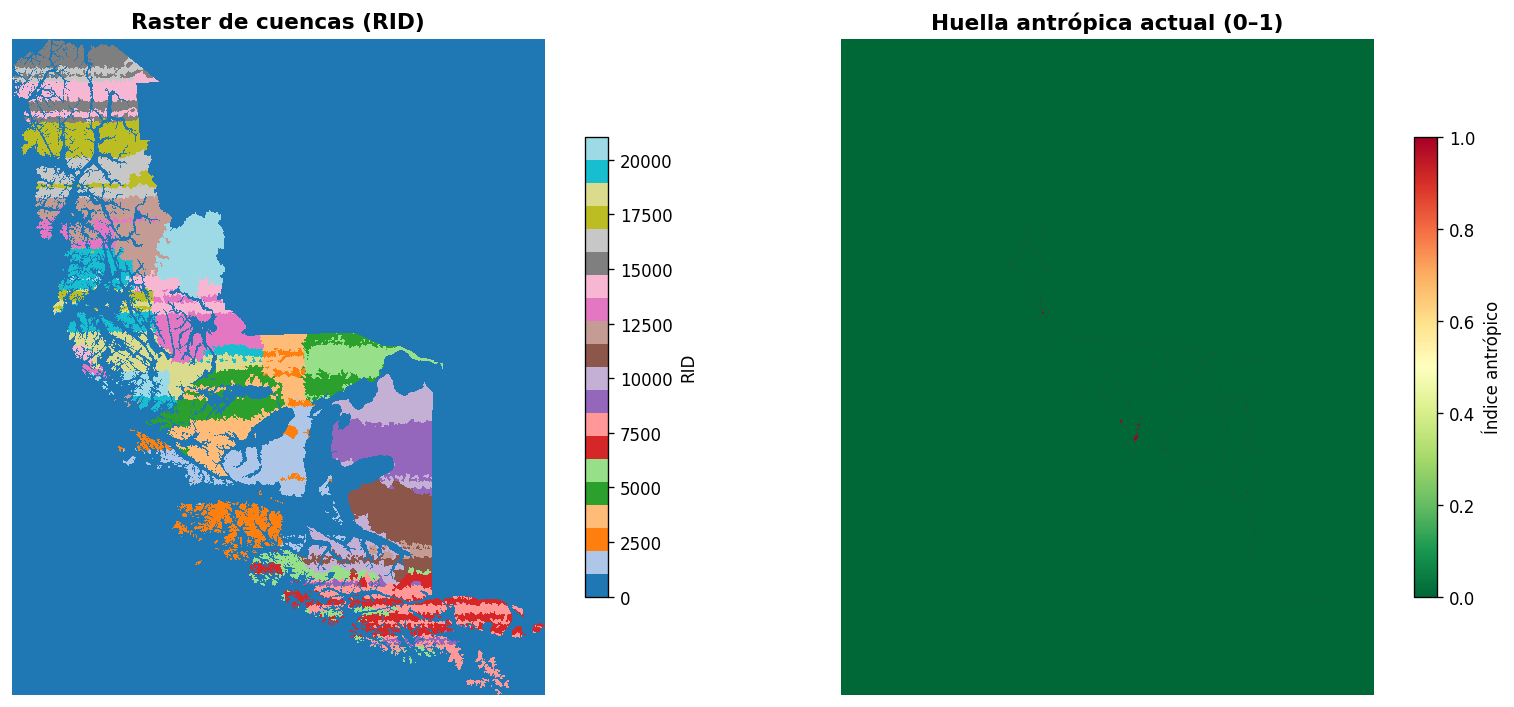

In [6]:
# ── Visualización: mapa de cuencas y huella antrópica ────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Raster de cuencas
ax = axes[0]
im = ax.imshow(basin_raster, cmap="tab20", interpolation="nearest")
ax.set_title("Raster de cuencas (RID)", fontsize=13, fontweight="bold")
ax.axis("off")
plt.colorbar(im, ax=ax, shrink=0.7, label="RID")

# Huella antrópica
ax = axes[1]
im = ax.imshow(anthropic, cmap="RdYlGn_r", vmin=0, vmax=1, interpolation="bilinear")
ax.set_title("Huella antrópica actual (0–1)", fontsize=13, fontweight="bold")
ax.axis("off")
plt.colorbar(im, ax=ax, shrink=0.7, label="Índice antrópico")

plt.tight_layout()
plt.show()

---
## Sección 4 — Indicadores Anuales por Cuenca

El primer paso de procesamiento consiste en convertir cada mosaico Landsat 8 anual en **14 indicadores escalares por cuenca**. Cada indicador resume una dimensión del estado ecosistémico.

### Lógica de procesamiento anual

```
Para cada año:
  1. Cargar 6 bandas: NDVI, NDWI, NDSI, NDDI, ALB, TB
  2. Construir máscara combinada (cuenca válida + natural + sin NaN)
  3. Clasificar píxeles: vegetación / agua / nieve / humedal
  4. Agregar por RID → 14 escalares por cuenca
```

---

### 4.1 Indicadores de Vegetación: VEG e IRV

**NDVI** (Normalized Difference Vegetation Index):
$$\text{NDVI} = \frac{\rho_{NIR} - \rho_{Red}}{\rho_{NIR} + \rho_{Red}} \in [-1, 1]$$

**VEG** — fracción de cobertura vegetal:
$$\text{VEG} = \frac{\sum_{p \in C} \mathbb{1}[NDVI_p \geq \theta_{veg}]}{|C|}$$

donde $C$ es el conjunto de píxeles válidos de la cuenca y $\theta_{veg}$ es el umbral (`thresh_veg = 0.2`).

**IRV** — Índice de Rigor Vegetativo (vigor):
$$\text{IRV} = \frac{\sum_{p: NDVI_p \geq \theta_{veg}} NDVI_p}{|\{p: NDVI_p \geq \theta_{veg}\}|}$$

IRV mide la intensidad del verdor solo en píxeles efectivamente vegetados. Una cuenca puede tener baja VEG pero alto IRV si la vegetación remanente es densa y saludable.

In [7]:
from mrct.indicators.vegetation import compute_veg_fraction, compute_irv
compute_veg_fraction

<function mrct.indicators.vegetation.compute_veg_fraction(veg_sum: 'np.ndarray', area: 'np.ndarray') -> 'np.ndarray'>

In [7]:
# ── Ejemplo: cargar mosaicos de un año específico y calcular VEG e IRV ────────
from mrct.preprocessing.annual_inputs import load_annual_mosaics
from mrct.preprocessing.masks import build_combined_mask
from mrct.indicators.vegetation import compute_veg_fraction, compute_irv

YEAR_DEMO = 2022  # 🔧 cambiar para explorar otros años

year_folder = config.mosaics_root / str(YEAR_DEMO) / "L8"
mosaics = load_annual_mosaics(YEAR_DEMO, year_folder, base_meta)

if mosaics is not None:
    ndvi = mosaics["ndvi"]

    # Máscara combinada: píxeles dentro de una cuenca, naturales y sin NaN
    combined_mask = build_combined_mask(basin_raster, natural_mask, ~np.isnan(ndvi))
    mask_flat = combined_mask.ravel().astype(bool)

    # Clasificación binaria de vegetación
    veg_bin = ((ndvi >= config.thresh_veg) & (natural_mask == 1)).astype(np.uint8)

    # Mapear píxeles a índice de cuenca (0..n_basins-1)
    flat_ids    = basin_raster.ravel()[mask_flat]
    flat_veg    = veg_bin.ravel()[mask_flat]
    flat_ndvi   = ndvi.ravel()[mask_flat]
    ids_mapped  = np.searchsorted(unique_rids, flat_ids)
    valid       = unique_rids[ids_mapped] == flat_ids
    ids_mapped, flat_veg, flat_ndvi = ids_mapped[valid], flat_veg[valid], flat_ndvi[valid]

    area    = np.bincount(ids_mapped, minlength=n_basins).astype(np.float32)
    veg_sum = np.bincount(ids_mapped, weights=flat_veg, minlength=n_basins).astype(np.float32)

    VEG = compute_veg_fraction(veg_sum, area)
    IRV = compute_irv(flat_veg, flat_ndvi, ids_mapped, n_basins)

    print(f"Año {YEAR_DEMO} — Resumen de indicadores de vegetación:")
    print(f"  VEG (fracción vegetada): media={VEG.mean():.3f}, max={VEG.max():.3f}")
    print(f"  IRV (vigor vegetativo) : media={IRV.mean():.3f}, max={IRV.max():.3f}")
    print(f"  Cuencas sin vegetación : {int((VEG == 0).sum())} / {n_basins}")
else:
    print(f"No se encontraron mosaicos para {YEAR_DEMO}")

NDVI desalineado. Reproyectando a grilla base.
NDWI desalineado. Reproyectando a grilla base.
NDSI desalineado. Reproyectando a grilla base.
NDDI desalineado. Reproyectando a grilla base.
ALB desalineado. Reproyectando a grilla base.
TB desalineado. Reproyectando a grilla base.


Año 2022 — Resumen de indicadores de vegetación:
  VEG (fracción vegetada): media=0.697, max=1.000
  IRV (vigor vegetativo) : media=0.493, max=0.999
  Cuencas sin vegetación : 3494 / 21040


### 4.2 Indicadores Hidrológicos: WA, HUM, IEH

**NDWI** (Normalized Difference Water Index):
$$\text{NDWI} = \frac{\rho_{Green} - \rho_{NIR}}{\rho_{Green} + \rho_{NIR}}$$

| Indicador | Fórmula | Interpretación |
|-----------|---------|----------------|
| **WA** | $\frac{|\{p: NDWI \geq \theta_w\}|}{|C|}$ | Fracción de agua superficial |
| **HUM** | $\frac{|\{p: \theta_{wet} \leq NDWI < \theta_w\}|}{|C|}$ | Fracción de humedales (zona de transición hídrica) |
| **IEH** | $\text{std}(NDWI_{p: NDWI \geq \theta_w})$ | Variabilidad espacial del agua — cuencas con alto IEH tienen distribución hídrica heterogénea |

> **¿Por qué IEH?** Una cuenca con agua concentrada en un solo lago tiene bajo IEH. Una cuenca con ríos, vegas y lagunas distribuidas tiene alto IEH. Mayor IEH refleja mayor diversidad hídrica y potencial regulatorio.

In [8]:
from mrct.indicators.hydrology import compute_water_fraction, compute_hum_fraction, compute_ieh

if mosaics is not None:
    ndwi = mosaics["ndwi"]
    flat_ndwi   = ndwi.ravel()[mask_flat][valid]

    water_bin   = ((ndwi >= config.thresh_water) & ~np.isnan(ndwi) & natural_mask).astype(np.uint8)
    wetland_bin = ((ndwi >= config.thresh_wetland) & (ndwi < config.thresh_water)).astype(np.uint8)

    flat_water   = water_bin.ravel()[mask_flat][valid]
    flat_wetland = wetland_bin.ravel()[mask_flat][valid]

    water_pix = np.bincount(ids_mapped, weights=flat_water,   minlength=n_basins).astype(np.float32)
    wet_sum   = np.bincount(ids_mapped, weights=flat_wetland, minlength=n_basins).astype(np.float32)

    WA  = compute_water_fraction(water_pix, area)
    HUM = compute_hum_fraction(wet_sum, area)
    IEH = compute_ieh(flat_water, flat_ndwi, ids_mapped, n_basins, water_pix)

    print(f"Año {YEAR_DEMO} — Indicadores hidrológicos:")
    print(f"  WA  (agua superficial): media={np.nanmean(WA):.4f}")
    print(f"  HUM (humedales)       : media={np.nanmean(HUM):.4f}")
    print(f"  IEH (variab. hídrica) : media={np.nanmean(IEH):.4f}")

Año 2022 — Indicadores hidrológicos:
  WA  (agua superficial): media=0.0231
  HUM (humedales)       : media=0.0213
  IEH (variab. hídrica) : media=0.1152


### 4.3 Criósfera: PN (Fracción de Nieve)

**NDSI** (Normalized Difference Snow Index):
$$\text{NDSI} = \frac{\rho_{Green} - \rho_{SWIR}}{\rho_{Green} + \rho_{SWIR}}$$

$$\text{PN} = \frac{|\{p: NDSI \geq \theta_{snow}\}|}{|C|}$$

En la Patagonia, PN es un proxy de la acumulación nival invernal y el deshielo. Un descenso de PN en años recientes puede indicar reducción de la criósfera por cambio climático.

### 4.4 Energía: ALB, TB, IA

| Variable | Fuente | Interpretación |
|----------|--------|----------------|
| **ALB** | Banda de albedo Landsat | Albedo superficial medio — superficies oscuras (vegetación densa, agua) tienen bajo ALB |
| **TB** | Banda térmica (Band 10) | Temperatura de brillo media en Kelvin |
| **IA** | NDDI medio | Índice de aridez — valores altos indican condiciones más secas |

**NDDI** (Normalized Difference Drought Index): sensible a estrés hídrico de la vegetación.

Estas tres variables forman el núcleo del **vector climático** usado para estimar la sensibilidad de cada cuenca a forzantes atmosféricos.

In [9]:
from mrct.indicators.cryosphere import compute_snow_fraction
from mrct.indicators.energy import compute_ia_mean, compute_albedo_mean, compute_tb_mean

if mosaics is not None:
    ndsi = mosaics["ndsi"]
    nddi = mosaics["nddi"]
    alb  = mosaics["alb"]
    tb   = mosaics["tb"]

    snow_bin  = (ndsi >= config.thresh_snow).astype(np.uint8)
    flat_snow = snow_bin.ravel()[mask_flat][valid]
    flat_nddi = nddi.ravel()[mask_flat][valid]
    flat_alb  = alb.ravel()[mask_flat][valid]
    flat_tb   = tb.ravel()[mask_flat][valid]

    snow_sum = np.bincount(ids_mapped, weights=flat_snow, minlength=n_basins).astype(np.float32)

    PN  = compute_snow_fraction(snow_sum, area)
    IA  = compute_ia_mean(flat_nddi, ids_mapped, area, n_basins)
    ALB = compute_albedo_mean(flat_alb, ids_mapped, area, n_basins)
    TB  = compute_tb_mean(flat_tb, ids_mapped, area, n_basins)

    print(f"Año {YEAR_DEMO} — Indicadores energéticos y criósfera:")
    print(f"  PN  (fracción nieve): media={PN.mean():.4f}")
    print(f"  IA  (aridez NDDI)   : media={IA.mean():.4f}")
    print(f"  ALB (albedo)        : media={ALB.mean():.4f}")
    print(f"  TB  (temp. brillo)  : media={TB.mean():.1f} K")

Año 2022 — Indicadores energéticos y criósfera:
  PN  (fracción nieve): media=0.1145
  IA  (aridez NDDI)   : media=-0.1046
  ALB (albedo)        : media=0.1708
  TB  (temp. brillo)  : media=236.4 K


### 4.5 Estructura del Paisaje: NP, MPA, PATCH_DENSITY, LPI, CONNECTIVITY

Las métricas de paisaje describen la **fragmentación** y **conectividad** de la vegetación dentro de cada cuenca. Son sensibles a cambios en el uso del suelo.

| Variable | Definición | Importancia ecológica |
|----------|-----------|----------------------|
| **NP** | Número de parches de vegetación | Más parches → mayor fragmentación |
| **MPA** | Tamaño medio de parche (píxeles) | Parches grandes → menor fragmentación |
| **PATCH_DENSITY** | NP / área de la cuenca (ha) | Normaliza NP por tamaño de cuenca |
| **LPI** | Tamaño del mayor parche / área total | Índice del parche dominante |
| **CONNECTIVITY** | $VEG \cdot \sqrt{MPA / VEG_{pix}}$ | Proxy de la permeabilidad ecológica |

El algoritmo usa **etiquetado de componentes conectadas** (scipy.ndimage.label) con conectividad de 8 vecinos para identificar los parches.

> 🔧 **Parámetro:** `connectivity = 8` (conectividad diagonal incluida). Cambiar a `4` para solo vecinos ortogonales.

In [10]:
from mrct.indicators.landscape import compute_landscape_metrics, compute_connectivity

if mosaics is not None:
    NP, MPA, PATCH_DENSITY, LPI = compute_landscape_metrics(
        basin_raster, veg_bin, combined_mask, unique_rids, n_basins,
        area, base_meta["transform"], config.connectivity,
    )
    CONNECTIVITY = compute_connectivity(veg_sum, area, MPA)

    print(f"Año {YEAR_DEMO} — Métricas de paisaje:")
    print(f"  NP            (nº parches)   : media={NP.mean():.1f}, max={NP.max():.0f}")
    print(f"  MPA           (tamaño medio) : media={MPA.mean():.1f} píx")
    print(f"  PATCH_DENSITY (por ha)       : media={PATCH_DENSITY.mean():.4f}")
    print(f"  LPI           (parche mayor) : media={LPI.mean():.4f}")
    print(f"  CONNECTIVITY  (conectividad) : media={CONNECTIVITY.mean():.4f}")

Año 2022 — Métricas de paisaje:
  NP            (nº parches)   : media=7.2, max=557
  MPA           (tamaño medio) : media=1841.2 píx
  PATCH_DENSITY (por ha)       : media=0.0892
  LPI           (parche mayor) : media=0.6551
  CONNECTIVITY  (conectividad) : media=0.4963


---
## Sección 5 — Hipercubo Tensorial y Panel RID × Año

Una vez calculados los 14 indicadores para un año, el proceso se repite para **todos los años**. El resultado es un **hipercubo de datos**:

$$\mathbf{T} \in \mathbb{R}^{N_{cuencas} \times N_{años} \times 14}$$

Luego se transforma en un **panel largo** (tidy data):

| RID | Year | VEG | IRV | NP | ... | TB |
|-----|------|-----|-----|----|-----|----|
| 1042 | 2013 | 0.54 | 0.38 | 12 | ... | 278 |
| 1042 | 2014 | 0.51 | 0.36 | 11 | ... | 281 |
| ... | ... | ... | ... | ... | ... | ... |

Este formato facilita las operaciones de ventana temporal (derivadas) y los joins espaciales (KNN).

In [12]:
from mrct.preprocessing.annual_inputs import process_annual_mosaics, VARIABLE_NAMES
from mrct.tensor.tensor_builder import init_data_cube, write_year_to_cube
from mrct.tensor.panel_builder import cube_to_panel, complete_panel_grid

print("Procesando mosaicos anuales...")
print(f"  Variables a calcular: {VARIABLE_NAMES}\n")

# Inicializar hipercubo: (n_basins, n_years, 14)
data_cube = init_data_cube(n_basins, len(config.years))

for y_idx, year in enumerate(config.years):
    result = process_annual_mosaics(
        year, config, base_meta, basin_raster, natural_mask, unique_rids, n_basins
    )
    if result is not None:
        write_year_to_cube(data_cube, y_idx, result)
        print(f"  ✅ {year} procesado")
    else:
        print(f"  ⚠️  {year} omitido (mosaicos incompletos)")

# Convertir a panel largo
df = cube_to_panel(data_cube, unique_rids, config.years)
df = complete_panel_grid(df, unique_rids, config.years)

# Reservar columnas para variables que se calculan a continuación
for col in ["Domain", "Domain_local", "Velocidad", "Aceleracion", "Jerk", "SENS", "PT", "RES"]:
    df[col] = np.nan

print(f"\nPanel construido: {len(df)} filas × {len(df.columns)} columnas")
print(f"  Estructura: {df['RID'].nunique()} cuencas × {df['Year'].nunique()} años")
df[["RID", "Year"] + VARIABLE_NAMES[:6]].head(10)

NDVI desalineado. Reproyectando a grilla base.


Procesando mosaicos anuales...
  Variables a calcular: ['VEG', 'IRV', 'NP', 'MPA', 'PATCH_DENSITY', 'LPI', 'CONNECTIVITY', 'IEH', 'HUM', 'PN', 'WA', 'IA', 'ALB', 'TB']



NDWI desalineado. Reproyectando a grilla base.
NDSI desalineado. Reproyectando a grilla base.
NDDI desalineado. Reproyectando a grilla base.
ALB desalineado. Reproyectando a grilla base.
TB desalineado. Reproyectando a grilla base.
NDVI desalineado. Reproyectando a grilla base.


  ✅ 2013 procesado


NDWI desalineado. Reproyectando a grilla base.
NDSI desalineado. Reproyectando a grilla base.
NDDI desalineado. Reproyectando a grilla base.
ALB desalineado. Reproyectando a grilla base.
TB desalineado. Reproyectando a grilla base.
NDVI desalineado. Reproyectando a grilla base.


...

NDWI desalineado. Reproyectando a grilla base.
NDSI desalineado. Reproyectando a grilla base.
NDDI desalineado. Reproyectando a grilla base.
ALB desalineado. Reproyectando a grilla base.
TB desalineado. Reproyectando a grilla base.
NDVI desalineado. Reproyectando a grilla base.


  ✅ 2024 procesado


NDWI desalineado. Reproyectando a grilla base.
NDSI desalineado. Reproyectando a grilla base.
NDDI desalineado. Reproyectando a grilla base.
ALB desalineado. Reproyectando a grilla base.
TB desalineado. Reproyectando a grilla base.


  ✅ 2025 procesado

Panel construido: 273520 filas × 24 columnas
  Estructura: 21040 cuencas × 13 años


,RID,Year,VEG,IRV,NP,MPA,PATCH_DENSITY,LPI
0,1,2013,0.992841,0.538514,7.0,832.142883,0.013257,0.990114
1,1,2014,0.995398,0.644278,6.0,973.333313,0.011363,0.992160
2,1,2015,0.993523,0.544150,6.0,971.500000,0.011363,0.990966
3,1,2016,0.994205,0.617970,5.0,1166.599976,0.009469,0.991819
4,1,2017,0.793932,0.511780,17.0,274.000000,0.032195,0.784728
5,1,2018,0.996080,0.594337,6.0,974.000000,0.011363,0.993694
6,1,2019,0.995228,0.539356,5.0,1167.800049,0.009469,0.993353
7,1,2020,0.997614,0.620007,7.0,836.142883,0.013257,0.993694
8,1,2021,0.989092,0.620023,5.0,1160.599976,0.009469,0.987046
9,1,2022,0.984149,0.586292,6.0,962.333313,0.011363,0.981933


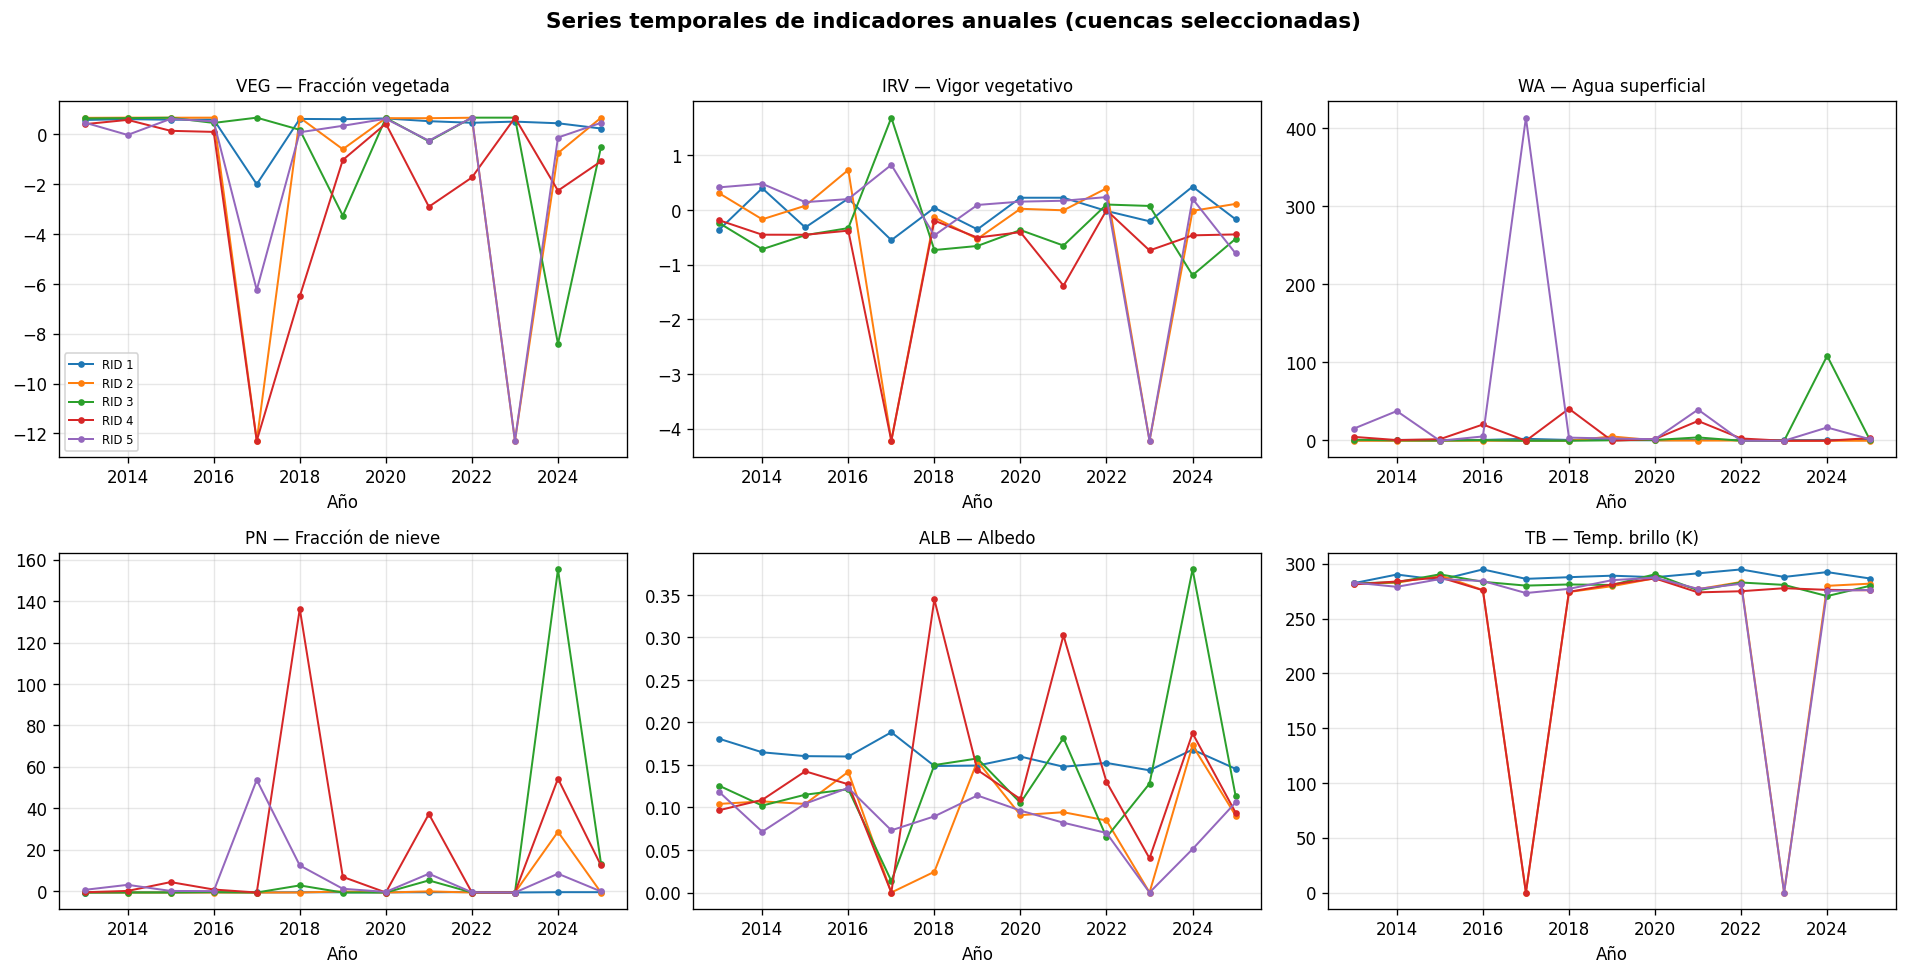

In [20]:
# ── Visualización: series temporales de indicadores para cuencas seleccionadas ─
selected_rids = unique_rids[:5]  # 🔧 cambiar para ver otras cuencas

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

indicators = [("VEG", "Fracción vegetada"), ("IRV", "Vigor vegetativo"),
              ("WA",  "Agua superficial"),  ("PN",  "Fracción de nieve"),
              ("ALB", "Albedo"),             ("TB",  "Temp. brillo (K)")]

for ax, (var, label) in zip(axes, indicators):
    for rid in selected_rids:
        sub = df[df["RID"] == rid].sort_values("Year")
        ax.plot(sub["Year"], sub[var], marker="o", markersize=3, linewidth=1.2, label=f"RID {rid}")
    ax.set_title(f"{var} — {label}", fontsize=10)
    ax.set_xlabel("Año")
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))
    ax.grid(alpha=0.3)

axes[0].legend(fontsize=7)
plt.suptitle("Series temporales de indicadores anuales (cuencas seleccionadas)",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

---
## Sección 6 — Dominio Ecosistémico Global

El **Dominio** es la variable central del modelo. Mide **cuán lejos se encuentra el estado actual de una cuenca respecto a su estado histórico de referencia**.

### 6.1 Selección de variables estructurales

No todas las variables son igual de informativas para definir el dominio. Se seleccionan las **11 variables estructurales** (excluyendo ALB, TB, IA que son climáticas) y se filtra las que tienen varianza suficiente durante el periodo baseline:

$$\mathcal{S} = \{v \in \{VEG, IRV, NP, MPA, \ldots\} : \sigma_v > 10^{-6}\}$$

### 6.2 Normalización Robusta

Se usa normalización **robust scaler** (no Z-score estándar) para evitar que outliers dominen:
$$x_{norm} = \frac{x - \text{mediana}_{baseline}}{\text{IQR}_{baseline}}$$

### 6.3 Estimación de Covarianza: Ledoit-Wolf

La covarianza del estado baseline se estima con el estimador **Ledoit-Wolf**, un estimador regularizado que funciona bien cuando $n_{muestras}$ es similar al número de variables:

$$\hat{\Sigma}_{LW} = (1-\alpha)\hat{\Sigma}_{sample} + \alpha \mu \mathbf{I}$$

donde $\alpha$ es el parámetro de encogimiento (*shrinkage*) estimado automáticamente.

### 6.4 Distancia de Mahalanobis

Para cada cuenca en cada año:
$$\text{Domain}(\mathbf{x}) = \sqrt{(\mathbf{x} - \boldsymbol{\mu})^T \hat{\Sigma}_{LW}^{-1} (\mathbf{x} - \boldsymbol{\mu})}$$

A diferencia de la distancia euclidea, Mahalanobis normaliza por la covarianza del sistema, por lo que es invariante a la escala y a las correlaciones entre variables.

**Interpretación:** `Domain = 0` → estado idéntico al baseline. `Domain = 3` → desviación de 3 desviaciones estándar multivariadas del estado de referencia.

> 🔧 **Parámetro:** `baseline_years` define el "estado normal" del ecosistema. Usar un baseline corto (e.g., 2013–2016) lo hace más sensible a cambios. El baseline largo (2013–2022) es más robusto pero puede enmascarar tendencias graduales.

In [35]:
import importlib
import mrct.domain.normalization
import mrct.domain.global_domain
importlib.reload(mrct.domain.normalization)
importlib.reload(mrct.domain.global_domain)
from mrct.domain.global_domain import fit_global_domain, compute_global_domain

In [36]:
 importlib.reload
 from mrct.domain.global_domain import fit_global_domain, compute_global_domain

# Ajustar el modelo de dominio sobre el periodo baseline
df, stable_cols, scaler_params, domain_model = fit_global_domain(df, config.baseline_years)

print("Modelo de dominio ajustado:")
print(f"  Variables estructurales seleccionadas: {stable_cols}")
print(f"  Baseline: {config.baseline_years}")
print(f"  Parámetros de normalización (mediana / IQR de cada variable):")
for v in stable_cols:
    med = scaler_params["median"][v]
    iqr = scaler_params["iqr"][v]
    print(f"    {v:15s}: med={med:.4f}, IQR={iqr:.4f}")

shrinkage = domain_model.get("shrinkage", "N/A")
print(f"\n  Parámetro de encogimiento Ledoit-Wolf: {shrinkage}")

# Calcular distancia de Mahalanobis para todos los años
df["Domain"] = compute_global_domain(
    df, stable_cols, domain_model, config.domain_metric, config.domain_bandwidth_q
)

print(f"\nDomain calculado para {df['Domain'].notna().sum()} observaciones")
print(f"  Domain media: {df['Domain'].mean():.3f}")
print(f"  Domain máx : {df['Domain'].max():.3f}")

Modelo de dominio ajustado:
  Variables estructurales seleccionadas: ['VEG', 'IRV', 'NP', 'MPA', 'PATCH_DENSITY', 'LPI', 'CONNECTIVITY', 'IEH', 'HUM', 'PN', 'WA']
  Baseline: [2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022]
  Parámetros de normalización (mediana / IQR de cada variable):
    VEG            : med=0.0000, IQR=1.0000
    IRV            : med=0.0000, IQR=1.0000
    NP             : med=0.0000, IQR=1.0000
    MPA            : med=0.0000, IQR=1.0000
    PATCH_DENSITY  : med=0.0000, IQR=1.0000
    LPI            : med=0.0000, IQR=1.0000
    CONNECTIVITY   : med=0.0000, IQR=1.0000
    IEH            : med=0.0000, IQR=1.0000
    HUM            : med=0.0000, IQR=1.0000
    PN             : med=0.0000, IQR=1.0000
    WA             : med=0.0000, IQR=1.0000

  Parámetro de encogimiento Ledoit-Wolf: N/A

Domain calculado para 152160 observaciones
  Domain media: 0.724
  Domain máx : 10.000


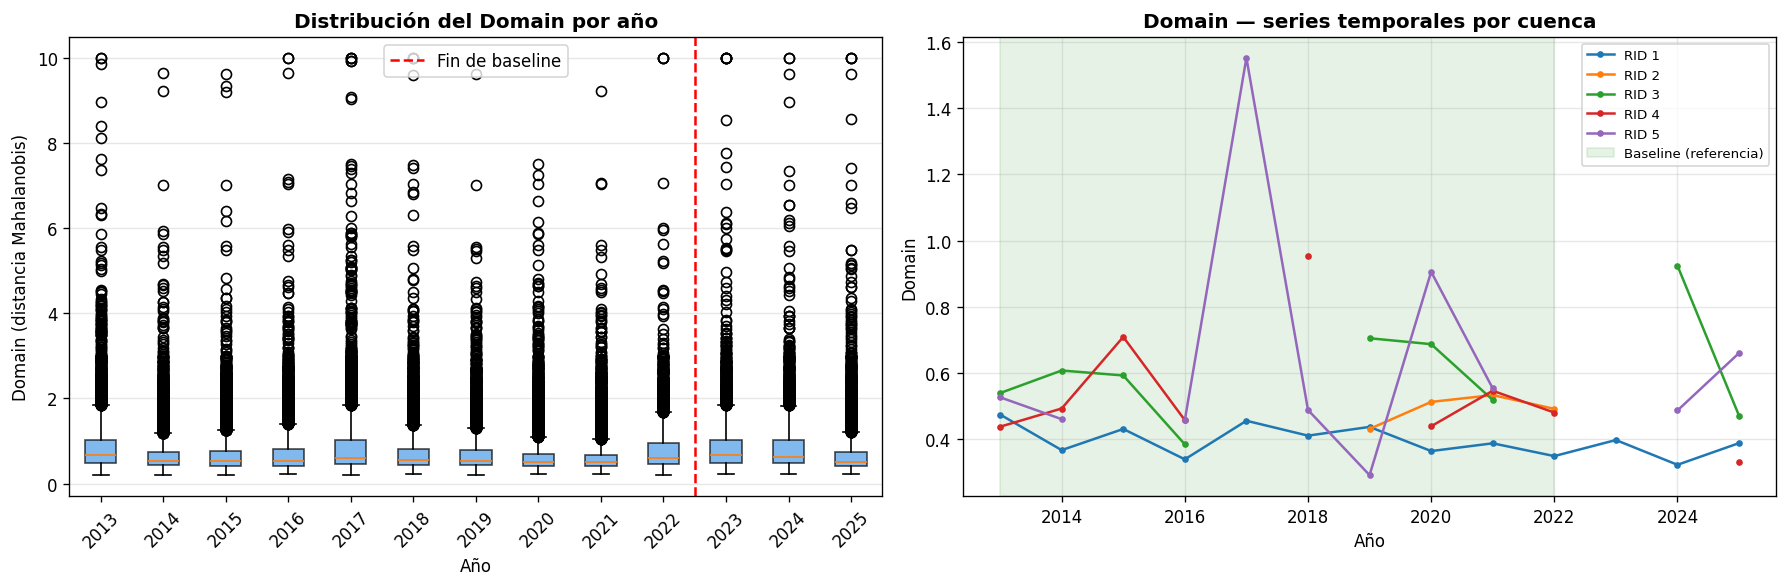

In [43]:
# ── Evolución temporal del Domain: distribución por año ──────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Boxplot por año
years_list  = sorted(df["Year"].unique())
domain_data = [df.loc[df["Year"] == y, "Domain"].dropna().values for y in years_list]
ax1.boxplot(domain_data, labels=years_list, patch_artist=True,
            boxprops=dict(facecolor="#4C9BE8", alpha=0.7))
ax1.axvline(x=len(config.baseline_years) + 0.5, color="red", linestyle="--",
            label="Fin de baseline")
ax1.set_title("Distribución del Domain por año", fontweight="bold")
ax1.set_xlabel("Año")
ax1.set_ylabel("Domain (distancia Mahalanobis)")
ax1.tick_params(axis="x", rotation=45)
ax1.legend()
ax1.grid(axis="y", alpha=0.3)

# Serie temporal para cuencas seleccionadas
for rid in selected_rids:
    sub = df[df["RID"] == rid].sort_values("Year")
    ax2.plot(sub["Year"], sub["Domain"], marker="o", markersize=3, linewidth=1.5, label=f"RID {rid}")

# Sombrear el periodo baseline
ax2.axvspan(config.baseline_years[0], config.baseline_years[-1],
            alpha=0.1, color="green", label="Baseline (referencia)")
ax2.set_title("Domain — series temporales por cuenca", fontweight="bold")
ax2.set_xlabel("Año")
ax2.set_ylabel("Domain")
ax2.legend(fontsize=8)
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

---
## Sección 7 — Dinámica Temporal

El Domain por sí solo indica distancia al baseline, pero no si el ecosistema **se está alejando, estabilizando o recuperando**. Las derivadas temporales del Domain capturan esa dinámica.

### Velocidad, Aceleración y Jerk

$$\text{Velocidad} = \frac{\Delta \text{Domain}}{\Delta t} \quad \text{(unidades: Domain/año)}$$

$$\text{Aceleración} = \frac{\Delta \text{Velocidad}}{\Delta t} \quad \text{(¿se acelera o desacelera el cambio?)}$$

$$\text{Jerk} = \frac{\Delta \text{Aceleración}}{\Delta t} \quad \text{(¿hay un cambio abrupto en el régimen?)}$$

| Variable | Valor positivo | Valor negativo |
|----------|---------------|----------------|
| Velocidad | Alejándose del baseline | Recuperándose |
| Aceleración | Degradación acelerándose | Degradación frenando |
| Jerk | Cambio de régimen acelerado | Cambio de régimen frenado |

In [44]:
from mrct.dynamics.derivatives import compute_temporal_derivatives
from mrct.dynamics.states import fit_dynamic_thresholds, apply_classify_state
from mrct.dynamics.semantic_labels import (
    classify_velocity, classify_acceleration, classify_jerk, classify_dynamic_regime
)

df = compute_temporal_derivatives(df)

print("Derivadas temporales calculadas:")
print(f"  Velocidad   — media: {df['Velocidad'].mean():.4f}, std: {df['Velocidad'].std():.4f}")
print(f"  Aceleración — media: {df['Aceleracion'].mean():.4f}, std: {df['Aceleracion'].std():.4f}")
print(f"  Jerk        — media: {df['Jerk'].mean():.4f}")

# Clasificación de régimen dinámico
eps_v, eps_a = fit_dynamic_thresholds(df, config.years[-1])
df = apply_classify_state(df, eps_v, eps_a)
df = classify_velocity(df)
df = classify_acceleration(df)
df = classify_jerk(df)
df = classify_dynamic_regime(df)

last = df[df["Year"] == config.years[-1]]
if "DYNAMIC_REGIME" in df.columns:
    print(f"\nClasificación de régimen dinámico ({config.years[-1]}):")
    print(last["DYNAMIC_REGIME"].value_counts().to_string())

Derivadas temporales calculadas:
  Velocidad   — media: -0.0226, std: 0.4766
  Aceleración — media: 0.0128, std: 0.8023
  Jerk        — media: -0.0230

Clasificación de régimen dinámico (2025):
DYNAMIC_REGIME
Mixto                       15279
Degradacion_Acelerada        2728
Crecimiento_Acelerado        1942
Recuperacion                  869
Crecimiento_Desacelerado      222


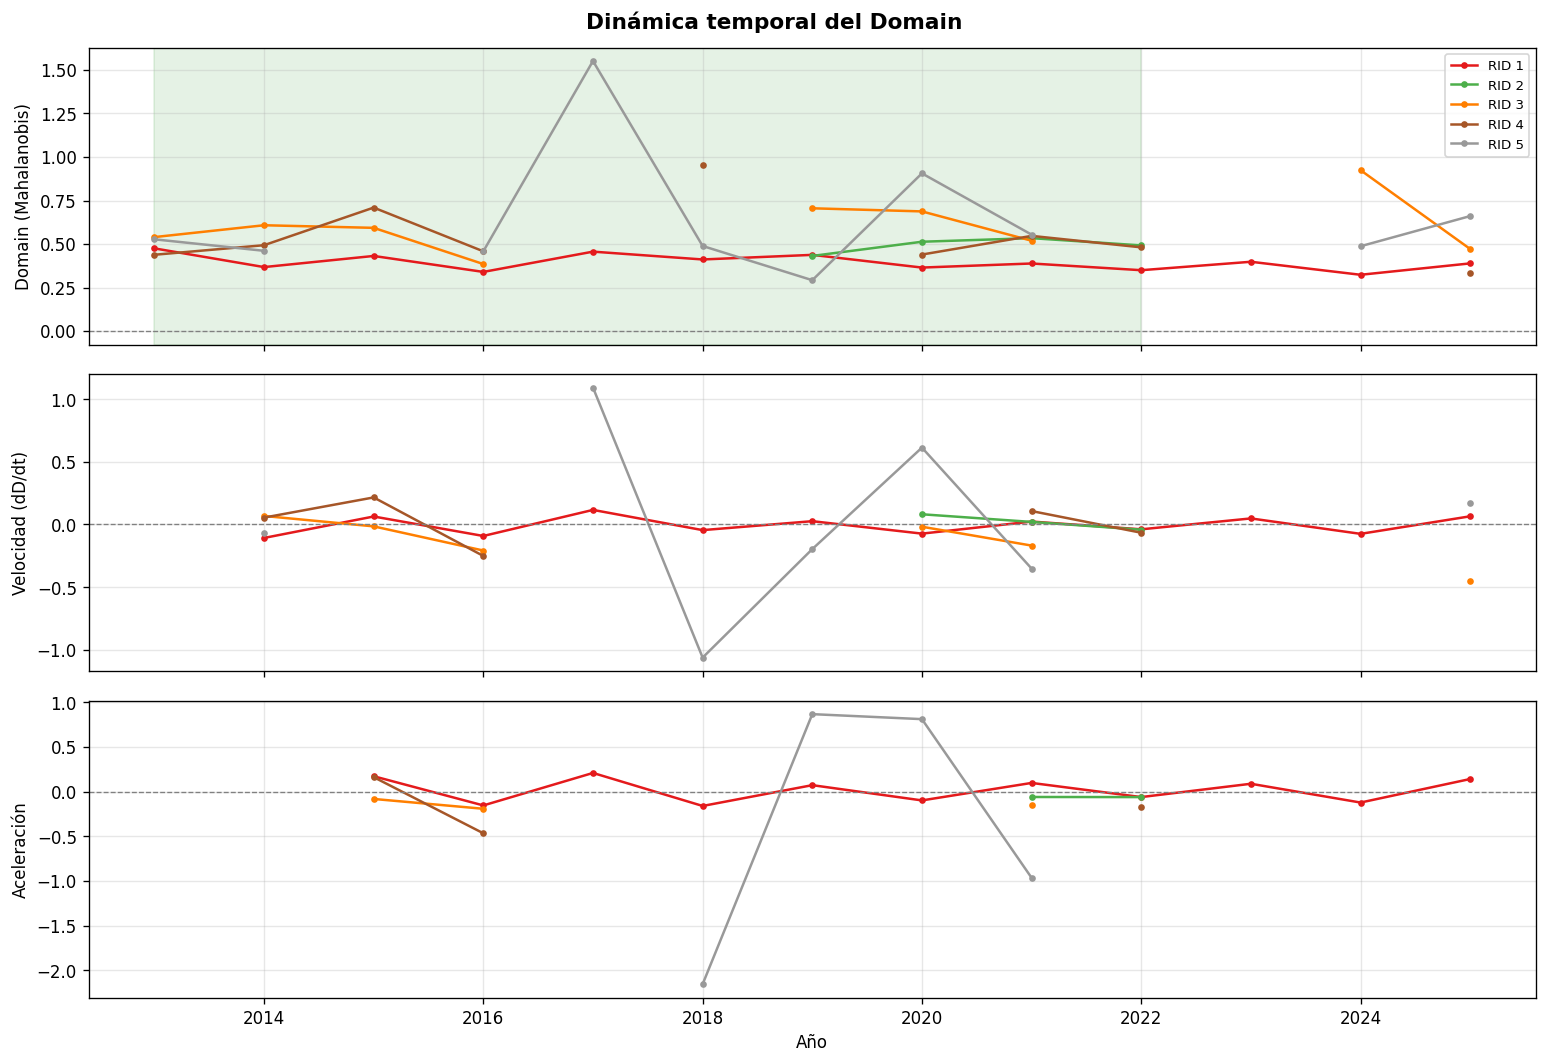

In [59]:
# ── Visualización: derivadas para cuencas seleccionadas ──────────────────────
fig, axes = plt.subplots(3, 1, figsize=(13, 9), sharex=True)
colors = plt.cm.Set1(np.linspace(0, 0.9, len(selected_rids)))

for (var, label, ax) in [
    ("Domain",     "Domain (Mahalanobis)", axes[0]),
    ("Velocidad",  "Velocidad (dD/dt)",    axes[1]),
    ("Aceleracion","Aceleración",          axes[2]),
]:
    for rid, color in zip(selected_rids, colors):
        sub = df[df["RID"] == rid].sort_values("Year")
        ax.plot(sub["Year"], sub[var], color=color, marker="o", markersize=3, linewidth=1.5,
                label=f"RID {rid}" if var == "Domain" else None)
    ax.axhline(0, color="gray", linestyle="--", linewidth=0.8)
    ax.set_ylabel(label)
    ax.grid(alpha=0.3)

axes[0].legend(fontsize=8)
axes[0].axvspan(config.baseline_years[0], config.baseline_years[-1],
                alpha=0.1, color="green", label="Baseline")
axes[2].set_xlabel("Año")
plt.suptitle("Dinámica temporal del Domain", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

---
## Sección 8 — Sensibilidad Climática y Dominio Local (KNN)

### 8.1 Sensibilidad Climática (SENS)

SENS cuantifica **cuánto responde el Domain de una cuenca a forzantes climáticos** (IA, ALB, TB). Se estima por regresión lineal múltiple para cada cuenca a lo largo del tiempo:

$$\text{Domain}_t = \beta_0 + \beta_1 IA_t + \beta_2 ALB_t + \beta_3 TB_t + \epsilon_t$$

$$\text{SENS} = \frac{\|\boldsymbol{\beta}_{1:3}\|}{\sigma_{Domain}}$$

Una cuenca con **alto SENS** es más vulnerable a años climáticamente extremos; su Domain fluctúa más ante sequías o anomalías térmicas.

### 8.2 Dominio Local mediante KNN

El contexto espacial importa: una cuenca puede estar degradada pero estar rodeada de cuencas saludables (o viceversa). El **dominio local** captura este efecto:

$$\text{Domain\_local}_i = \frac{\sum_{j \in \mathcal{N}_k(i)} w_{ij} \cdot \text{Domain}_{j}}{\sum_{j \in \mathcal{N}_k(i)} w_{ij}}$$

donde $\mathcal{N}_k(i)$ son las $k$ cuencas más cercanas (por distancia entre centroides) y $w_{ij} = 1/d_{ij}$.

> 🔧 **Parámetro:** `knn_k = 8` — cuencas vecinas consideradas. Aumentar k suaviza el dominio local; reducirlo lo hace más local.

In [46]:
from mrct.sensitivity.climate import compute_climate_sensitivity
from mrct.domain.local_domain import compute_knn_neighborhood, compute_local_domain

# ─── Sensibilidad climática ───────────────────────────────────────────────────
df_sens = compute_climate_sensitivity(df, unique_rids, n_basins)
df["SENS"] = df["RID"].map(df_sens.set_index("RID")["SENS"])
df["Domain_mask"] = (~df["Domain"].isna()).astype(np.uint8)

print("Sensibilidad climática (SENS):")
print(f"  Media  : {df_sens['SENS'].mean():.4f}")
print(f"  Máximo : {df_sens['SENS'].max():.4f}")
print(f"  Cuencas con SENS > 1: {int((df_sens['SENS'] > 1).sum())}")

# ─── KNN y dominio local ──────────────────────────────────────────────────────
distances, indices = compute_knn_neighborhood(basin_gdf, unique_rids, config.knn_k)
df["Domain_local"] = compute_local_domain(
    df, unique_rids, config.years, stable_cols, distances, indices
)
df["DIV"] = (df["Domain_local"] - df["Domain"]) / (df["Domain"] + 1e-6)

print(f"\nDominio local (Domain_local):")
print(f"  Media  : {df['Domain_local'].mean():.3f}")
print(f"\nDivergencia local (DIV = Domain_local/Domain - 1):")
print(f"  Media  : {df['DIV'].mean():.4f}")
print(f"  Cuencas en contexto más degradado (DIV < -0.2): "
      f"{int((df['DIV'] < -0.2).sum())}")

Sensibilidad climática (SENS):
  Media  : 4.5986
  Máximo : 17435.2285
  Cuencas con SENS > 1: 9794

Dominio local (Domain_local):
  Media  : 146.366

Divergencia local (DIV = Domain_local/Domain - 1):
  Media  : 201.4113
  Cuencas en contexto más degradado (DIV < -0.2): 7


---
## Sección 9 — Potencial de Transición y Resiliencia

### 9.1 Potencial de Transición (PT)

El PT integra cuatro señales del estado ecosistémico en un único índice de riesgo de transición de estado:

$$\text{PT} = \underbrace{\text{Domain}}_{\text{distancia al baseline}} \cdot \underbrace{(1 + |\text{Velocidad}|)}_{\text{dinamismo}} \cdot \underbrace{(1 + \alpha \cdot \text{SENS})}_{\text{sensibilidad climática}} \cdot \underbrace{(1 + \beta_{local} \cdot \text{Domain\_local})}_{\text{contexto espacial}}$$

**Lectura componente a componente:**
- **Domain** — cuán lejos está la cuenca de su estado histórico
- **(1 + |Velocidad|)** — si la cuenca se está moviendo rápido en el espacio de estados, el riesgo sube
- **(1 + α·SENS)** — cuencas climáticamente sensibles amplifican el riesgo  
- **(1 + β_local·Domain_local)** — si el entorno también está degradado, el riesgo es mayor

> 🔧 **Parámetros clave:** `alpha` pondera la sensibilidad climática; `beta_local` pondera el contexto espacial. `alpha=0` ignora la sensibilidad climática; `beta_local=0` ignora el entorno.

### 9.2 Índice de Resiliencia (RES)

$$\text{RES} = \frac{1}{1 + PT} \in (0, 1]$$

Esta transformación logística invierte el PT: **cuanto mayor el PT, menor la resiliencia**. `RES = 1` es resiliencia máxima (PT = 0 → cuenca en estado baseline exacto). `RES → 0` indica alta vulnerabilidad.

### 9.3 Gradiente Espacial de Resiliencia (RES_GRAD)

$$\text{RES\_GRAD}_i = \text{RES}_i - \frac{1}{k} \sum_{j \in \mathcal{N}_k(i)} \text{RES}_j$$

Una cuenca con **RES_GRAD > 0** es un "oasis de resiliencia" en un entorno más degradado (alta prioridad de conservación). RES_GRAD < 0 indica que la cuenca es el eslabón débil de una red ecosistémica sana.

In [47]:
from mrct.resilience.pt import compute_transition_potential
from mrct.resilience.res import compute_resilience
from mrct.resilience.gradients import compute_resilience_gradient
from mrct.resilience.resilience_types import classify_resilience_type, classify_resilience_state

# Calcular PT y RES
df["PT"]  = compute_transition_potential(df, config.alpha, config.beta_local)
df["RES"] = compute_resilience(df["PT"])

# Gradiente espacial
df["RES_GRAD"] = compute_resilience_gradient(df, unique_rids, config.years, distances, indices)

# Clasificaciones de resiliencia
df = classify_resilience_type(df)
df["RES_STATE"] = df.apply(classify_resilience_state, axis=1)

last = df[df["Year"] == config.years[-1]]
print(f"Resiliencia en {config.years[-1]}:")
print(f"  RES media  : {last['RES'].mean():.4f}")
print(f"  RES mínima : {last['RES'].min():.4f}  (cuenca más vulnerable)")
print(f"  PT media   : {last['PT'].mean():.4f}")

if "RES_TYPE" in df.columns:
    print(f"\nDistribución de tipos de resiliencia:")
    print(last["RES_TYPE"].value_counts().to_string())

Resiliencia en 2025:
  RES media  : 0.4622
  RES mínima : 0.0000  (cuenca más vulnerable)
  PT media   : 290.9750

Distribución de tipos de resiliencia:
RES_TYPE
Transicion                12557
Resiliencia_Estable        4757
Resiliencia_Tensionada     2319
Degradacion_Activa         1016
Recuperacion_Ecologica      391


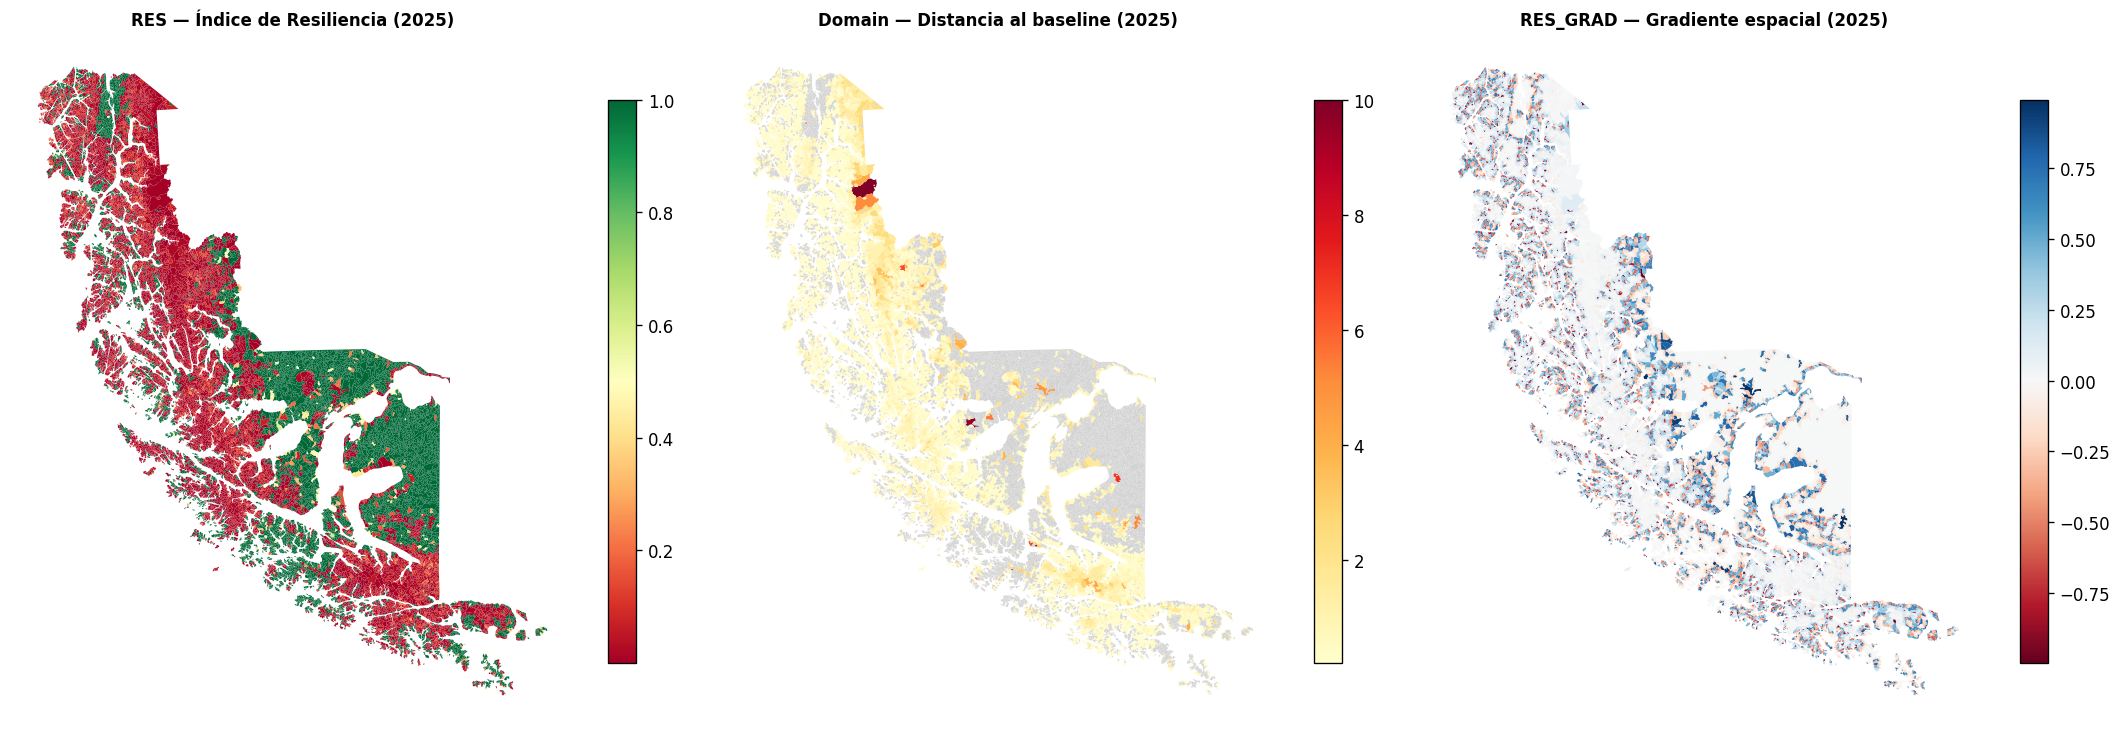

In [48]:
# ── Visualización: mapa coroplético de RES en el último año ──────────────────
last_year = config.years[-1]
res_last  = df[df["Year"] == last_year][["RID", "RES", "PT", "Domain", "RES_GRAD"]]

gdf_res = basin_gdf.reset_index().merge(res_last, on="RID", how="left")

fig, axes = plt.subplots(1, 3, figsize=(18, 7))

for ax, (col, cmap, label) in zip(axes, [
    ("RES",      "RdYlGn",    f"RES — Índice de Resiliencia ({last_year})"),
    ("Domain",   "YlOrRd",    f"Domain — Distancia al baseline ({last_year})"),
    ("RES_GRAD", "RdBu",      f"RES_GRAD — Gradiente espacial ({last_year})"),
]):
    gdf_res.plot(column=col, cmap=cmap, legend=True, ax=ax,
                 legend_kwds={"shrink": 0.7}, missing_kwds={"color": "lightgrey"})
    ax.set_title(label, fontsize=10, fontweight="bold")
    ax.axis("off")

plt.tight_layout()
plt.show()

In [49]:
# ── Sensibilidad de RES a parámetros alpha y beta_local ──────────────────────
# Esta celda permite explorar cómo cambia RES ante distintas combinaciones
# de alpha (peso climático) y beta_local (peso espacial)

print("Análisis de sensibilidad: RES media según alpha y beta_local\n")
print(f"{'alpha':>8} {'beta_local':>12} {'RES media':>12} {'RES mín':>10}")
print("-" * 46)

for alpha_test in [0.5, 1.0, 1.5, 2.0]:
    for beta_test in [0.2, 0.5, 0.8]:
        pt_test  = compute_transition_potential(df, alpha_test, beta_test)
        res_test = compute_resilience(pt_test)
        res_last_mean = res_test[df["Year"] == last_year].mean()
        res_last_min  = res_test[df["Year"] == last_year].min()
        print(f"  {alpha_test:>6.1f}   {beta_test:>10.1f}   {res_last_mean:>10.4f}   {res_last_min:>8.4f}")

Análisis de sensibilidad: RES media según alpha y beta_local

   alpha   beta_local    RES media    RES mín
----------------------------------------------
     0.5          0.2       0.4940     0.0000
     0.5          0.5       0.4691     0.0000
     0.5          0.8       0.4609     0.0000
     1.0          0.2       0.4818     0.0000
     1.0          0.5       0.4622     0.0000
     1.0          0.8       0.4558     0.0000
     1.5          0.2       0.4745     0.0000
     1.5          0.5       0.4580     0.0000
     1.5          0.8       0.4527     0.0000
     2.0          0.2       0.4695     0.0000
     2.0          0.5       0.4552     0.0000
     2.0          0.8       0.4507     0.0000


---
## Sección 10 — Escenario Prospectivo

La simulación prospectiva proyecta el estado ecosistémico de cada cuenca **bajo un escenario de cambio antrópico futuro**. No es una predicción; es un análisis de sensibilidad: *¿qué pasaría si la huella humana aumentara según el escenario dado?*

### Cadena de cálculo

```
1. ANTHRO_CHANGE = huella_futura - huella_actual (por cuenca)
2. Spillover     = propagar el cambio hacia cuencas vecinas
3. Fragmentación = amplificar NP, reducir MPA y CONNECTIVITY
4. Estructura futura = proyectar VEG, IRV, etc. con el cambio
5. Domain_future = recomputar distancia Mahalanobis con estructura futura
6. PT_future, RES_future = aplicar fórmulas de PT y RES
7. DELTA_RES = RES_future - RES_actual
```

### 🔧 Parámetros del escenario

| Parámetro | Efecto |
|-----------|--------|
| `frag_alpha = 0.6` | Intensidad del impacto de fragmentación. Mayor → más parches, menor MPA |
| `spillover = 0.3` | Fracción del cambio antrópico que "derrama" hacia cuencas vecinas. Mayor → efectos más extendidos |

In [53]:
from mrct.preprocessing.anthropic import compute_delta_anthropic, compute_anthropic_change
from mrct.pipeline.run_pipeline import run_scenario_pipeline

# Cargar huella antrópica futura
if config.scenario_anthropic_raster and config.scenario_anthropic_raster.exists():
    anthropic_future = read_aligned_raster(config.scenario_anthropic_raster, base_meta, "ANTHROPIC_FUTURE")
    anthropic_future = np.nan_to_num(anthropic_future, nan=0)
    print("Raster de escenario futuro cargado.")
else:
    anthropic_future = anthropic.copy()
    print("⚠️  Raster futuro no encontrado. Usando huella actual (sin cambio escenario).")

delta_anthropic = compute_delta_anthropic(anthropic, anthropic_future)
change_map = compute_anthropic_change(
    delta_anthropic, anthropic, natural_mask, basin_raster, unique_rids
)

cuencas_impactadas = sum(1 for v in change_map.values() if v > 0)
print(f"\nCambio antrópico por cuenca:")
print(f"  Cuencas con cambio positivo: {cuencas_impactadas} / {n_basins}")
if change_map:
    cambios = list(change_map.values())
    print(f"  Cambio medio: {np.mean(cambios):.4f}")
    print(f"  Cambio máximo: {np.max(cambios):.4f}")

ANTHROPIC_FUTURE desalineado. Reproyectando a grilla base.


Raster de escenario futuro cargado.

Cambio antrópico por cuenca:
  Cuencas con cambio positivo: 1332 / 21040
  Cambio medio: 0.0004
  Cambio máximo: 0.9231


In [54]:
# ── Ejecutar pipeline de escenario prospectivo ────────────────────────────────
df_future = run_scenario_pipeline(
    df, basin_gdf, unique_rids, distances, indices,
    stable_cols, scaler_params, domain_model, change_map, config,
)

last_fut = df_future[df_future["Year"] == config.years[-1]]

print("Resultados del escenario prospectivo:")
print(f"  RES actual media   : {last_fut['RES'].mean():.4f}")
print(f"  RES futura media   : {last_fut['RES_future'].mean():.4f}")
print(f"  DELTA_RES media    : {last_fut['DELTA_RES'].mean():.4f}")
print(f"  Cuencas que mejoran (DELTA_RES > 0): {int((last_fut['DELTA_RES'] > 0).sum())}")
print(f"  Cuencas que empeoran (DELTA_RES < 0): {int((last_fut['DELTA_RES'] < 0).sum())}")

Resultados del escenario prospectivo:
  RES actual media   : 0.4622
  RES futura media   : 0.4622
  DELTA_RES media    : 0.0000
  Cuencas que mejoran (DELTA_RES > 0): 1508
  Cuencas que empeoran (DELTA_RES < 0): 10347


---
## Sección 11 — Métricas de Riesgo Territorial

### SHOCK_INDEX — Magnitud del impacto ecosistémico

$$\text{SHOCK\_INDEX} = \text{clip}_{[0,10]}\bigl(0.5 |\Delta D| + 0.3 |\Delta \text{Vel}| + 0.2 |\text{Jerk}|\bigr)$$

Combina la magnitud del cambio de dominio inducido, el cambio de velocidad y la curvatura dinámica. Refleja el **impacto súbito** sobre la estructura ecosistémica.

### TRI — Territorial Risk Index

$$\text{TRI} = \text{SHOCK\_INDEX} \cdot \max(0, 1 - \text{ECO\_ELASTICITY}) \cdot |\Delta \text{RES}|$$

El TRI pondera el shock por **la incapacidad de recuperarse** (1 - elasticidad ecológica) y por **la magnitud de la pérdida de resiliencia**. Un ecosistema elástico puede absorber un shock grande sin alto TRI.

### ETEI — Ecosystem Transition Ecosystem Index

Clasificación categórica del tipo de transición:
- `Sistema_Estable` — cambio inducido dentro de variabilidad histórica
- `Tension_Ecosistemica` — cambio de dominio y velocidad aumentan
- `Aceleracion_Degradativa` — aceleración del cambio supera umbral
- `Shock_Ecosistemico` — SHOCK_INDEX en el percentil 85 o superior
- `Recuperacion_Inducida` — cambio prospectivo mejora el dominio

### DECISION_ZONE — Aptitud territorial

| Zona | TRI_CLASS | Significado |
|------|-----------|-------------|
| Zona_Apta | Riesgo_Bajo | Inversión territorial compatible |
| Zona_Mitigacion | Riesgo_Moderado | Requiere medidas de mitigación |
| Zona_Condicionada | Riesgo_Alto | Solo con plan ambiental estricto |
| Zona_No_Apta | Riesgo_Critico | No aprobar inversión |

In [55]:
last_fut = df_future[df_future["Year"] == config.years[-1]]

print("=" * 55)
print(f"  MÉTRICAS DE RIESGO TERRITORIAL — AÑO {config.years[-1]}")
print("=" * 55)

for col, label in [
    ("SHOCK_INDEX", "SHOCK_INDEX"),
    ("TRI",         "TRI"),
    ("ETEI_INDEX",  "ETEI_INDEX"),
    ("DELTA_RES",   "DELTA_RES"),
]:
    if col in last_fut.columns:
        vals = last_fut[col].dropna()
        print(f"  {label:14s}: media={vals.mean():8.4f}, max={vals.max():8.4f}")

print()
for col, label in [("TRI_CLASS", "TRI_CLASS"), ("DECISION_ZONE", "DECISION_ZONE"), ("ETEI", "ETEI")]:
    if col in last_fut.columns:
        print(f"\n  Distribución de {label}:")
        print(last_fut[col].value_counts().to_string())

  MÉTRICAS DE RIESGO TERRITORIAL — AÑO 2025
  SHOCK_INDEX   : media=  0.3348, max=  4.9814
  TRI           : media=  0.0000, max=  0.0000
  ETEI_INDEX    : media= -0.0023, max=  4.2128
  DELTA_RES     : media=  0.0000, max=  0.0032


  Distribución de TRI_CLASS:
TRI_CLASS
Riesgo_Bajo        17529
Riesgo_Alto         2056
Riesgo_Critico      1200
Riesgo_Moderado      255

  Distribución de DECISION_ZONE:
DECISION_ZONE
Zona_Apta            17529
Zona_Condicionada     2056
Zona_No_Apta          1200
Zona_Mitigacion        255

  Distribución de ETEI:
ETEI
Transicion_Indeterminada    14093
Sistema_Estable              4741
Aceleracion_Degradativa      1027
Tension_Ecosistemica          782
Recuperacion_Inducida         248
Shock_Ecosistemico            149


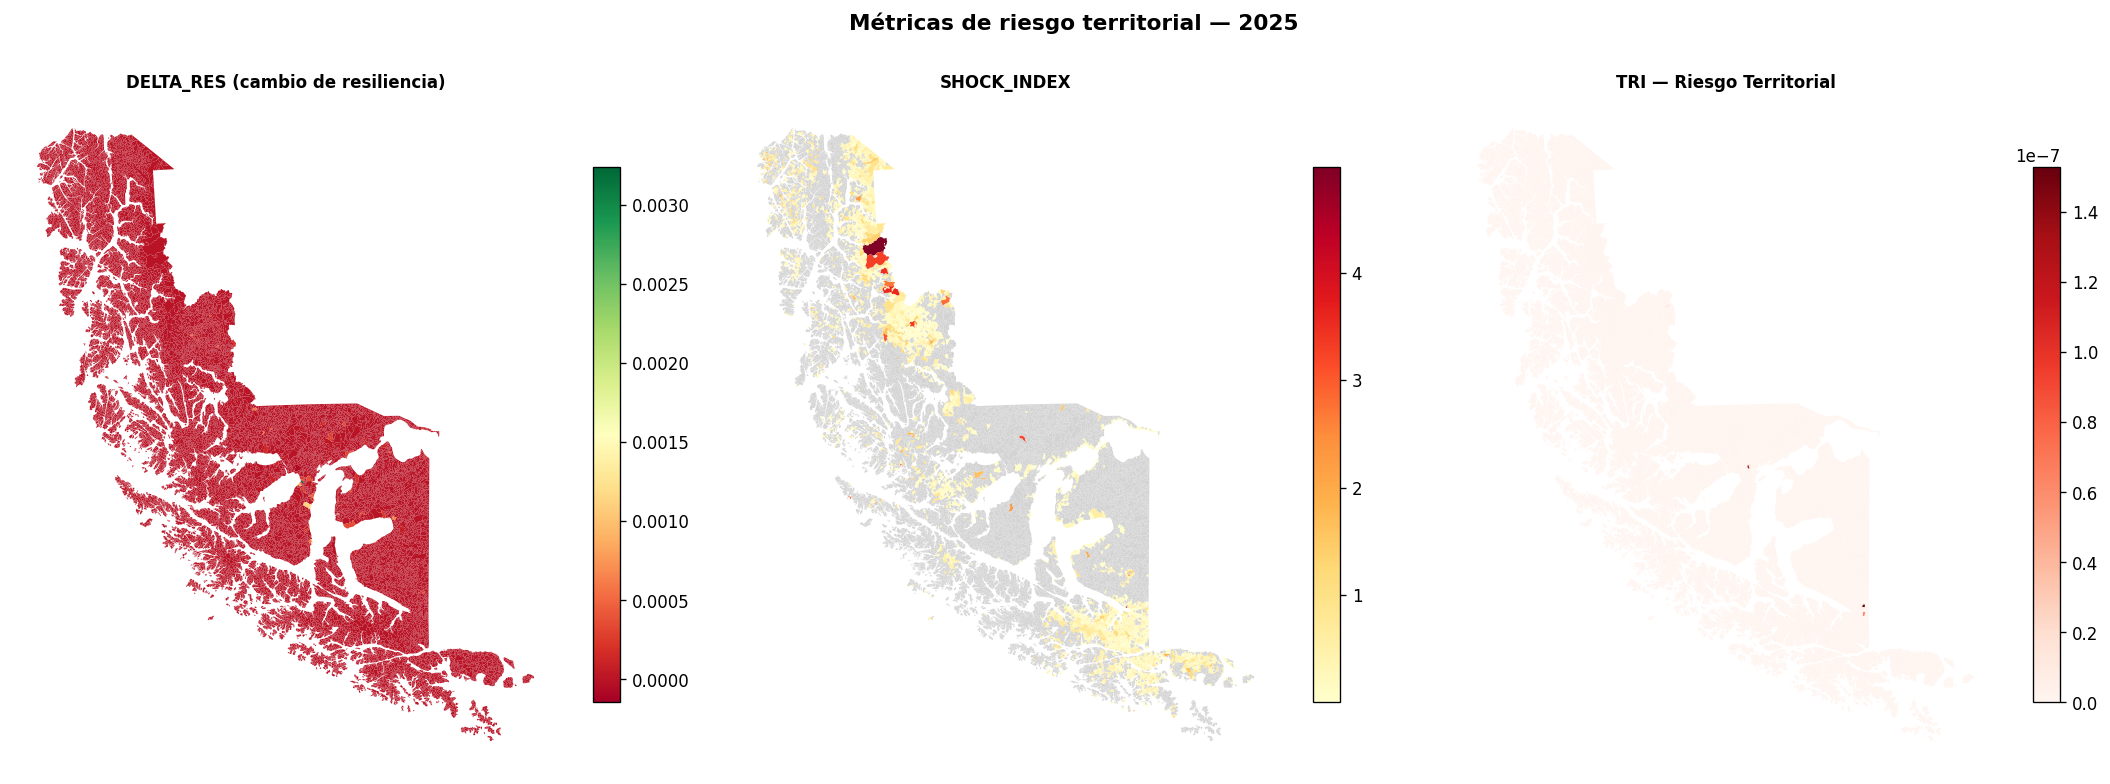

In [56]:
# ── Visualización: mapas de riesgo territorial ────────────────────────────────
risk_cols = [
    ("DELTA_RES",    "RdYlGn",  "DELTA_RES (cambio de resiliencia)"),
    ("SHOCK_INDEX",  "YlOrRd",  "SHOCK_INDEX"),
    ("TRI",          "Reds",    "TRI — Riesgo Territorial"),
]

available = [(c, cmap, lbl) for c, cmap, lbl in risk_cols if c in last_fut.columns]
if available:
    fig, axes = plt.subplots(1, len(available), figsize=(6 * len(available), 7))
    if len(available) == 1:
        axes = [axes]

    for ax, (col, cmap, label) in zip(axes, available):
        gdf_risk = basin_gdf.reset_index().merge(last_fut[["RID", col]], on="RID", how="left")
        gdf_risk.plot(column=col, cmap=cmap, legend=True, ax=ax,
                     legend_kwds={"shrink": 0.7},
                     missing_kwds={"color": "lightgrey"})
        ax.set_title(label, fontsize=10, fontweight="bold")
        ax.axis("off")

    plt.suptitle(f"Métricas de riesgo territorial — {config.years[-1]}",
                 fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.show()

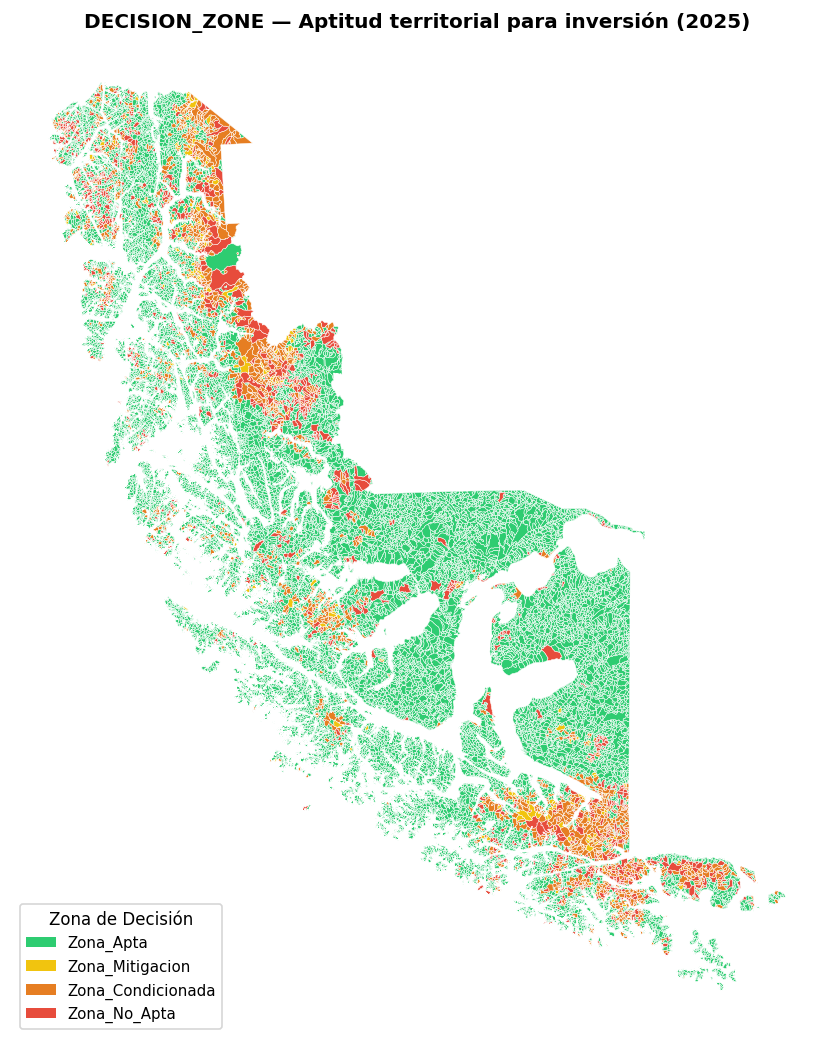

In [57]:
# ── Mapa de zonas de decisión ─────────────────────────────────────────────────
if "DECISION_ZONE" in last_fut.columns:
    zone_colors = {
        "Zona_Apta"        : "#2ecc71",
        "Zona_Mitigacion"  : "#f1c40f",
        "Zona_Condicionada": "#e67e22",
        "Zona_No_Apta"     : "#e74c3c",
    }
    gdf_decision = basin_gdf.reset_index().merge(
        last_fut[["RID", "DECISION_ZONE"]], on="RID", how="left"
    )
    gdf_decision["color"] = gdf_decision["DECISION_ZONE"].map(zone_colors).fillna("lightgrey")

    fig, ax = plt.subplots(figsize=(10, 9))
    gdf_decision.plot(color=gdf_decision["color"], ax=ax, edgecolor="white", linewidth=0.3)

    from matplotlib.patches import Patch
    legend_elements = [Patch(facecolor=v, label=k) for k, v in zone_colors.items()]
    ax.legend(handles=legend_elements, loc="lower left", title="Zona de Decisión", fontsize=9)
    ax.set_title(f"DECISION_ZONE — Aptitud territorial para inversión ({config.years[-1]})",
                 fontsize=12, fontweight="bold")
    ax.axis("off")
    plt.tight_layout()
    plt.show()

---
## Sección 12 — Exportación de Resultados

El modelo genera múltiples formatos de salida:

| Archivo | Formato | Uso |
|---------|---------|-----|
| `MRCT_v1.nc` | NetCDF | Análisis cuantitativo, series temporales completas |
| `MRCT_v1.xlsx` | Excel | Revisión, reportes, filtros |
| `MRCT_state.shp` | Shapefile | Estado actual en GIS |
| `MRCT_future.shp` | Shapefile | Proyección futura en GIS |
| `MRCT_risk.shp` | Shapefile | Métricas de riesgo en GIS |
| `MRCT_v1.gpkg` | GeoPackage | Una sola capa consolidada |
| `MRCT_field_dictionary.xlsx` | Excel | Diccionario de campos |

In [60]:
import importlib, mrct.io.writers
importlib.reload(mrct.io.writers)
from mrct.io.writers import build_state_layer, build_future_layer, build_risk_layer,export_shapefiles, export_field_dictionary, export_netcdf

In [61]:
from mrct.io.writers import (
    build_state_layer, build_future_layer, build_risk_layer,
    export_shapefiles, export_field_dictionary, export_netcdf,
)
from mrct.preprocessing.annual_inputs import VARIABLE_NAMES

config.output_folder.mkdir(parents=True, exist_ok=True)

last_year = config.years[-1]
state_gdf  = build_state_layer(df, basin_gdf, last_year)
future_gdf = build_future_layer(df_future, basin_gdf, last_year)
risk_gdf   = build_risk_layer(df_future, basin_gdf, last_year)

# Shapefiles
gis_dir = config.output_folder / "gis"
export_shapefiles(state_gdf, future_gdf, risk_gdf, gis_dir)

# GeoPackage consolidado
basin_out = basin_gdf.reset_index().merge(df[df.Year == last_year], on="RID", how="left")
basin_out.to_file(config.output_folder / "MRCT_v1.gpkg", driver="GPKG")

# Excel
df_future.to_excel(config.output_folder / "MRCT_v1.xlsx", index=False)
export_field_dictionary(state_gdf, config.output_folder / "MRCT_field_dictionary.xlsx")

# NetCDF
all_vars = VARIABLE_NAMES + [
    "Domain", "Domain_local", "Velocidad", "Aceleracion", "SENS", "PT",
    "Domain_mask", "Jerk", "DIV", "RES_GRAD",
]
future_vars = [
    "Domain_future", "RES_future", "DELTA_RES", "DELTA_DOMAIN",
    "VEL_INDUCIDA", "DELTA_VEL", "ACC_INDUCIDA", "SHOCK_INDEX",
    "TRI", "ETEI_INDEX", "RES_LOSS_PCT", "ECO_ELASTICITY",
]
export_netcdf(
    df, df_future, unique_rids, config.years, all_vars, future_vars,
    config.output_folder / "MRCT_v1.nc",
    config_str=str(config), baseline_years_str=str(config.baseline_years),
)

print("✅ Exportación completa:")
for f in sorted(config.output_folder.rglob("*.*")):
    size_mb = f.stat().st_size / 1e6
    print(f"  {f.relative_to(config.output_folder)}  ({size_mb:.1f} MB)")

✅ Exportación completa:
  .DS_Store  (0.0 MB)
  MRCT_field_dictionary.xlsx  (0.0 MB)
  MRCT_v1.gpkg  (76.8 MB)
  MRCT_v1.nc  (16.0 MB)
  MRCT_v1.xlsx  (162.7 MB)
  gis/MRCT_future.cpg  (0.0 MB)
  gis/MRCT_future.dbf  (65.4 MB)
  gis/MRCT_future.prj  (0.0 MB)
  gis/MRCT_future.shp  (59.2 MB)
  gis/MRCT_future.shx  (0.2 MB)
  gis/MRCT_risk.cpg  (0.0 MB)
  gis/MRCT_risk.dbf  (21.3 MB)
  gis/MRCT_risk.prj  (0.0 MB)
  gis/MRCT_risk.shp  (59.2 MB)
  gis/MRCT_risk.shx  (0.2 MB)
  gis/MRCT_state.cpg  (0.0 MB)
  gis/MRCT_state.dbf  (38.0 MB)
  gis/MRCT_state.prj  (0.0 MB)
  gis/MRCT_state.shp  (59.2 MB)
  gis/MRCT_state.shx  (0.2 MB)


---
## Bonus — Pipeline completo en una sola celda

Si ya tienes todos los insumos y quieres ejecutar el modelo completo sin pasar por cada sección, usa las funciones de pipeline de alto nivel:

In [ ]:
# ── Pipeline completo (alternativa a ejecutar sección por sección) ────────────
# from mrct.pipeline.run_pipeline import run_full_pipeline
#
# run_full_pipeline(config)
#
# O en dos pasos para acceder a los resultados intermedios:
# from mrct.pipeline.run_pipeline import run_base_pipeline, run_scenario_pipeline
#
# (df, basin_gdf, unique_rids, distances, indices,
#  stable_cols, scaler_params, domain_model, change_map) = run_base_pipeline(config)
#
# df_future = run_scenario_pipeline(
#     df, basin_gdf, unique_rids, distances, indices,
#     stable_cols, scaler_params, domain_model, change_map, config
# )

print("Descomenta el código de arriba para ejecutar el pipeline completo.")
print("Requiere que todos los insumos espaciales estén disponibles.")

---
## Resumen de parámetros modificables

```python
config = MRCTConfig(
    # ── Umbrales de clasificación temática ──────────────────────────────────
    thresh_veg     = 0.2,   # NDVI mínimo para vegetación
    thresh_water   = 0.2,   # NDWI mínimo para agua
    thresh_snow    = 0.4,   # NDSI mínimo para nieve

    # ── Definición del estado de referencia ────────────────────────────────
    baseline_years = list(range(2013, 2023)),  # años que definen el "normal"

    # ── Métricas de distancia ecosistémica ─────────────────────────────────
    domain_metric  = "mahalanobis",  # o "bisquare" (más robusto a outliers)

    # ── Resiliencia: pesos del PT ───────────────────────────────────────────
    alpha          = 1.0,   # peso sensibilidad climática en PT
    beta_local     = 0.5,   # peso dominio espacial local en PT
    knn_k          = 8,     # vecinos KNN para dominio local

    # ── Escenario prospectivo ───────────────────────────────────────────────
    frag_alpha     = 0.6,   # intensidad fragmentación inducida
    spillover      = 0.3,   # propagación espacial del cambio
)
```

---

**¿Dudas sobre el modelo?** Contactar a John Treimun Ríos: john.treimun.r@uai.cl  
**¿Dudas sobre el código y flujo de trabajo?** Contactar a Denis Berroeta: denis.berroeta@uai.cl  
**Repositorio:** MRCT-2026 / CIT-UAI